# Notebook 08 — Transformer-Encoder (PatchTST-lite)

**Detector de anomalías basado en un Transformer-Encoder con atención multi-cabeza** sobre ventanas temporales de smart-meter. Aplica directamente la **sesión 12 de NLP (atención, Q/K/V, multi-head, codificación posicional)** al dominio de series temporales energéticas.

**Inspirado en PatchTST** (Nie et al., ICLR 2023): en lugar de tratar cada timestep como un token, agrupamos la ventana de 60 min en *patches* de 5 minutos (12 patches por ventana), cada patch se proyecta linealmente a un embedding de `d_model=64`, se le suma la codificación posicional aprendida, y pasa por 2 bloques transformer encoder. La salida se decodifica con un MLP simétrico para reconstruir la ventana.

**Ventajas teóricas vs LSTM-AE:**
- Procesa todos los patches **en paralelo** (no secuencial → mejor en Metal GPU).
- Atención global captura dependencias largas sin gradient vanishing.
- Estado del arte en time-series 2023-2024 (Informer, Autoformer, PatchTST, iTransformer).

Hiperparámetros pequeños para entrenar en M2 Pro en <10 min:
- `window=60, patch_len=5 → n_patches=12`
- `d_model=64, n_heads=4, ffn_dim=128, n_layers=2`
- `~50k parámetros`, comparable a LSTM-AE (57k).


## 0. Setup

In [2]:
import os, json, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

# ─── TensorFlow + Metal (M2 Pro) ─────────────────────────────────────────────
import tensorflow as tf
tf.random.set_seed(42)

# Metal GPU detection
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
        except Exception:
            pass
    print(f"  Metal GPU: {gpus[0].name}")
else:
    print("  Metal GPU: NO detectada (CPU fallback)")

# Note: NO usamos mixed_float16 (incompatible con Metal). XLA tampoco.
tf.keras.mixed_precision.set_global_policy('float32')

print(f"  TensorFlow: {tf.__version__}")
print('OK')

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, LayerNormalization, Dropout,
                                     MultiHeadAttention, Add, Reshape, Embedding)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    f1_score, fbeta_score, precision_score, recall_score,
    average_precision_score, precision_recall_curve
)
import joblib


  Metal GPU: /physical_device:GPU:0
  TensorFlow: 2.18.1
OK


## 1. Carga de Datos Reales

In [3]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),
                       index_col='datetime', parse_dates=True)
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),
                       index_col='datetime', parse_dates=True)
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),
                       index_col='datetime', parse_dates=True)

print('DATOS CARGADOS (UCI real)')
print('=' * 65)
for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    pos = (d['label']==1).sum() if 'label' in d.columns else 0
    print(f'  {nm:6s} {len(d):>9,d}   ataques: {pos:>7,d}')


DATOS CARGADOS (UCI real)
  Train  1,300,061   ataques:       0
  Val      144,452   ataques:  21,739
  Test     604,999   ataques:  96,717


## 2. Feature Engineering (mode = `medium` + vi_res_abs)

In [4]:
def compute_features(df, mode='full'):
    '''Mismo extractor que NB02/NB04. base=8, medium=13, full=17.'''
    f = df[FEATURE_COLS].copy()
    f['VI_residual'] = (
        df['Global_active_power']
        - df['Voltage'] * df['Global_intensity'] / 1000.0
    )
    if mode in ('medium', 'full'):
        h = df.index.hour + df.index.minute / 60.0
        f['hour_sin'] = np.sin(2 * np.pi * h / 24)
        f['hour_cos'] = np.cos(2 * np.pi * h / 24)
        d = df.index.dayofweek
        f['dow_sin'] = np.sin(2 * np.pi * d / 7)
        f['dow_cos'] = np.cos(2 * np.pi * d / 7)
        f['gap_diff1'] = df['Global_active_power'].diff().fillna(0)
    if mode == 'full':
        f['vi_res_abs']         = f['VI_residual'].abs()
        f['vi_res_roll15_mean'] = f['vi_res_abs'].rolling(15, min_periods=1).mean()
        f['gap_intensity_ratio']= df['Global_active_power'] / (df['Global_intensity'] + 0.01)
        f['sm_gap_ratio']       = ((df['Sub_metering_1'] + df['Sub_metering_2']
                                    + df['Sub_metering_3']) / 1000.0
                                   / (df['Global_active_power'] + 0.01))
    return f.fillna(0)

FEATURE_MODE = 'medium'
X_train_df = compute_features(df_train, mode=FEATURE_MODE)
X_val_df   = compute_features(df_val,   mode=FEATURE_MODE)
X_test_df  = compute_features(df_test,  mode=FEATURE_MODE)

for d in (X_train_df, X_val_df, X_test_df):
    d['vi_res_abs'] = d['VI_residual'].abs()

ENG_FEATURE_COLS = list(X_train_df.columns)
print(f'Features ({len(ENG_FEATURE_COLS)}): {ENG_FEATURE_COLS}')

y_val  = df_val['label'].values  if 'label' in df_val.columns  else None
y_test = df_test['label'].values if 'label' in df_test.columns else None

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_df.values).astype('float32')
X_val   = scaler.transform(X_val_df.values).astype('float32')
X_test  = scaler.transform(X_test_df.values).astype('float32')

N_FEATURES = X_train.shape[1]
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')


Features (14): ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1', 'vi_res_abs']
Train: (1300061, 14)  Val: (144452, 14)  Test: (604999, 14)


## 3. Ventanas + Patches

In [5]:
WINDOW = 60
PATCH_LEN = 5
N_PATCHES = WINDOW // PATCH_LEN          # 12 patches
STRIDE_TRAIN = 30
STRIDE_EVAL  = 1

def make_windows(X, window=WINDOW, stride=1):
    n = len(X)
    if n < window:
        return np.empty((0, window, X.shape[1]), dtype='float32')
    starts = np.arange(0, n - window + 1, stride)
    return np.stack([X[s:s+window] for s in starts]).astype('float32')

def to_patches(Xw, patch_len=PATCH_LEN):
    '''(N, window, F) -> (N, n_patches, patch_len*F)'''
    N, W, F = Xw.shape
    Xp = Xw.reshape(N, W // patch_len, patch_len, F)
    return Xp.reshape(N, W // patch_len, patch_len * F)

t0 = time.time()
Xw_train = make_windows(X_train, WINDOW, STRIDE_TRAIN)
Xw_val   = make_windows(X_val,   WINDOW, STRIDE_EVAL)
Xw_test  = make_windows(X_test,  WINDOW, STRIDE_EVAL)

Xp_train = to_patches(Xw_train)
Xp_val   = to_patches(Xw_val)
Xp_test  = to_patches(Xw_test)
print(f'Ventanas: train {Xw_train.shape}  val {Xw_val.shape}  test {Xw_test.shape}')
print(f'Patches:  train {Xp_train.shape}  val {Xp_val.shape}  test {Xp_test.shape}')
print(f'Patch dim: {PATCH_LEN}*{N_FEATURES} = {PATCH_LEN*N_FEATURES}')
print(f'Tiempo: {time.time()-t0:.1f}s')


Ventanas: train (43334, 60, 14)  val (144393, 60, 14)  test (604940, 60, 14)
Patches:  train (43334, 12, 70)  val (144393, 12, 70)  test (604940, 12, 70)
Patch dim: 5*14 = 70
Tiempo: 4.0s


## 4. Arquitectura del Transformer-Encoder

In [6]:
D_MODEL  = 64
N_HEADS  = 4
FFN_DIM  = 128
N_LAYERS = 2
DROPOUT  = 0.1

def transformer_encoder_block(x, d_model, n_heads, ffn_dim, dropout, name):
    '''Pre-LN encoder block (mas estable en Metal que post-LN).'''
    # Self-attention
    a = LayerNormalization(name=f'{name}_ln1')(x)
    a = MultiHeadAttention(num_heads=n_heads, key_dim=d_model // n_heads,
                           dropout=dropout, name=f'{name}_mha')(a, a, a)
    x = Add(name=f'{name}_add1')([x, a])

    # FFN
    f = LayerNormalization(name=f'{name}_ln2')(x)
    f = Dense(ffn_dim, activation='gelu', name=f'{name}_ffn1')(f)
    f = Dropout(dropout, name=f'{name}_dropout')(f)
    f = Dense(d_model, name=f'{name}_ffn2')(f)
    x = Add(name=f'{name}_add2')([x, f])
    return x


def build_transformer_autoencoder(n_patches, patch_dim,
                                  d_model=D_MODEL, n_heads=N_HEADS,
                                  ffn_dim=FFN_DIM, n_layers=N_LAYERS,
                                  dropout=DROPOUT):
    inp = Input(shape=(n_patches, patch_dim), name='patches')

    # Proyeccion patch -> embedding
    x = Dense(d_model, name='patch_proj')(inp)

    # Codificacion posicional aprendida (sesion 12 de NLP)
    pos_ids = tf.range(start=0, limit=n_patches, delta=1)
    pos_emb = Embedding(input_dim=n_patches, output_dim=d_model, name='pos_emb')(pos_ids)
    x = x + pos_emb     # broadcast (1, n_patches, d_model)

    # Encoder layers
    for i in range(n_layers):
        x = transformer_encoder_block(x, d_model, n_heads, ffn_dim, dropout, name=f'enc{i+1}')

    # Bottleneck: reduce dimension via projection
    x = LayerNormalization(name='enc_final_ln')(x)
    bottleneck = Dense(d_model // 4, activation='gelu', name='bottleneck')(x)

    # Decoder: simple MLP por patch que reconstruye el patch original
    d = Dense(d_model, activation='gelu', name='dec_proj')(bottleneck)
    d = Dropout(dropout, name='dec_drop')(d)
    out = Dense(patch_dim, name='reconstruction')(d)

    model = Model(inp, out, name='transformer_autoencoder')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss='mse',
        jit_compile=False,   # XLA off en Metal
    )
    return model


PATCH_DIM = PATCH_LEN * N_FEATURES
ae = build_transformer_autoencoder(N_PATCHES, PATCH_DIM)
ae.summary()


2026-05-20 14:41:13.500409: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-05-20 14:41:13.501337: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-20 14:41:13.501407: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1779280873.510199   12530 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1779280873.510970   12530 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "transformer_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patches             │ (None, 12, 70)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_proj (Dense)  │ (None, 12, 64)    │      4,544 │ patches[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 12, 64)    │          0 │ patch_proj[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_ln1            │ (None, 12, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_mha            │ (None, 12, 64)    │     16,640 │ enc1_ln1[0][0],   │
│ (MultiHeadAttentio… │                   │            │ enc1_ln1[0][0],   │
│                     │                   │            │ enc1_ln1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_add1 (Add)     │ (None, 12, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ enc1_mha[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_ln2            │ (None, 12, 64)    │        128 │ enc1_add1[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_ffn1 (Dense)   │ (None, 12, 128)   │      8,320 │ enc1_ln2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_dropout        │ (None, 12, 128)   │          0 │ enc1_ffn1[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_ffn2 (Dense)   │ (None, 12, 64)    │      8,256 │ enc1_dropout[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_add2 (Add)     │ (None, 12, 64)    │          0 │ enc1_add1[0][0],  │
│                     │                   │            │ enc1_ffn2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_ln1            │ (None, 12, 64)    │        128 │ enc1_add2[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_mha            │ (None, 12, 64)    │     16,640 │ enc2_ln1[0][0],   │
│ (MultiHeadAttentio… │                   │            │ enc2_ln1[0][0],   │
│                     │                   │            │ enc2_ln1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_add1 (Add)     │ (None, 12, 64)    │          0 │ enc1_add2[0][0],  │
│                     │                   │            │ enc2_mha[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_ln2            │ (None, 12, 64)    │        128 │ enc2_add1[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_ffn1 (Dense)   │ (None, 12, 128)   │      8,320 │ enc2_ln2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_dropout        │ (None, 12, 128)   │          0 │ enc2_ffn1[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_ffn2 (Dense)   │ (None, 12, 64)    │      8,256 │ enc2_dropout[0][

 Total params: 78,294 (305.84 KB)

 Trainable params: 78,294 (305.84 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento (Metal-optimised)

Epoch 1/30


2026-05-20 14:41:17.926644: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


153/153 ━━━━━━━━━━━━━━━━━━━━ 18s 61ms/step - loss: 32.6746 - val_loss: 19.7230 - learning_rate: 5.0000e-04
Epoch 2/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 17.0403 - val_loss: 6.6565 - learning_rate: 5.0000e-04
Epoch 3/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 6.0121 - val_loss: 1.8758 - learning_rate: 5.0000e-04
Epoch 4/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - loss: 3.0946 - val_loss: 1.1497 - learning_rate: 5.0000e-04
Epoch 5/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 2.4771 - val_loss: 0.9650 - learning_rate: 5.0000e-04
Epoch 6/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 2.2132 - val_loss: 0.8696 - learning_rate: 5.0000e-04
Epoch 7/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 2.0606 - val_loss: 0.8153 - learning_rate: 5.0000e-04
Epoch 8/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 1.9443 - val_loss: 0.7609 - learning_rate: 5.0000e-04
Epoch 9/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - loss: 1.8528 - val_loss: 0.7320 

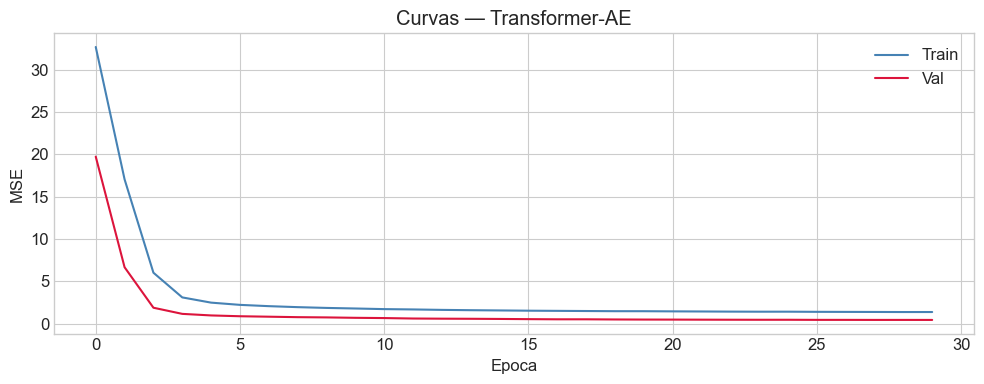

In [7]:
def make_tfdataset(X, batch_size=256, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, X))
    if shuffle:
        ds = ds.shuffle(8192, seed=42, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

BATCH = 256
val_split = int(0.9 * len(Xp_train))
ds_train = make_tfdataset(Xp_train[:val_split], batch_size=BATCH, shuffle=True)
ds_val   = make_tfdataset(Xp_train[val_split:], batch_size=BATCH, shuffle=False)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

t0 = time.time()
history = ae.fit(
    ds_train,
    epochs=30,
    validation_data=ds_val,
    callbacks=callbacks,
    verbose=1
)
t_train = time.time() - t0
print(f'\nEntrenamiento: {t_train:.1f}s | {len(history.history["loss"])} epocas')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], 'steelblue', label='Train')
ax.plot(history.history['val_loss'], 'crimson', label='Val')
ax.set(xlabel='Epoca', ylabel='MSE', title='Curvas — Transformer-AE')
ax.legend()
plt.tight_layout(); plt.show()


## 6. Score por ventana + expansion a timesteps

In [8]:
def calibrate_threshold(y_true, scores, beta=1.0):
    '''Busca umbral que maximiza F_beta usando precision_recall_curve.'''
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    precisions = precisions[:-1]
    recalls    = recalls[:-1]
    fbeta = ((1 + beta**2) * precisions * recalls /
             (beta**2 * precisions + recalls + 1e-10))
    best_idx = np.argmax(fbeta)
    best_thr = thresholds[best_idx]
    return best_thr, precisions[best_idx], recalls[best_idx], fbeta[best_idx]

def reconstruction_errors_per_patch(model, Xp, batch_size=512):
    '''Error MSE por (window, patch).'''
    rec = model.predict(Xp, batch_size=batch_size, verbose=0)
    return ((rec - Xp)**2).mean(axis=2)    # (N, n_patches)

# Pesos: damos mas peso a patches con error promedio mayor en train
err_train = reconstruction_errors_per_patch(ae, Xp_train, batch_size=1024)
patch_weights = err_train.mean(axis=0)
patch_weights = patch_weights / patch_weights.sum()
print(f'Patch weights (longitud {len(patch_weights)}):')
print(patch_weights.round(3))

def score_per_window(model, Xp, w, batch_size=1024):
    rec = model.predict(Xp, batch_size=batch_size, verbose=0)
    err = ((rec - Xp)**2).mean(axis=2)         # (N, n_patches)
    return (err * w).sum(axis=1)                # (N,)

scores_val_w  = score_per_window(ae, Xp_val,  patch_weights, batch_size=1024)
scores_test_w = score_per_window(ae, Xp_test, patch_weights, batch_size=1024)
print(f'scores_val_w: {scores_val_w.shape}  scores_test_w: {scores_test_w.shape}')


Patch weights (longitud 12):
[0.083 0.085 0.085 0.083 0.083 0.082 0.083 0.084 0.084 0.082 0.083 0.083]
scores_val_w: (144393,)  scores_test_w: (604940,)


## 7. Expansión a 1 score/min

In [9]:
def expand_window_scores(scores_w, n_total, window=WINDOW, stride=1):
    scores_ts = np.full(n_total, np.nan, dtype='float32')
    starts = np.arange(0, n_total - window + 1, stride)
    for s, sc in zip(starts, scores_w):
        end = s + window
        scores_ts[s:end] = np.maximum(np.nan_to_num(scores_ts[s:end], nan=-np.inf), sc)
    nan_mask = np.isnan(scores_ts)
    if nan_mask.any():
        first_valid = np.argmax(~nan_mask)
        scores_ts[nan_mask] = scores_ts[first_valid]
    return scores_ts

scores_val  = expand_window_scores(scores_val_w,  len(df_val),  WINDOW, STRIDE_EVAL)
scores_test = expand_window_scores(scores_test_w, len(df_test), WINDOW, STRIDE_EVAL)
print(f'scores_val: {scores_val.shape}  scores_test: {scores_test.shape}')

best_thr, prec_at, rec_at, fbeta_at = calibrate_threshold(y_val, scores_val, beta=1.0)
print(f'best_thr: {best_thr:.6f}  | P={prec_at:.4f} R={rec_at:.4f} F1={fbeta_at:.4f}')


scores_val: (144452,)  scores_test: (604999,)
best_thr: 2.347566  | P=0.4946 R=0.5883 F1=0.5374


## 8. Evaluacion RAW

In [10]:
y_pred_raw = (scores_test > best_thr).astype(int)
auc_roc = roc_auc_score(y_test, scores_test)
auc_pr  = average_precision_score(y_test, scores_test)
f1_r   = f1_score(y_test, y_pred_raw)
f2_r   = fbeta_score(y_test, y_pred_raw, beta=2)
prec_r = precision_score(y_test, y_pred_raw)
rec_r  = recall_score(y_test, y_pred_raw)

print('='*60); print('TRANSFORMER-AE — RAW'); print('='*60)
print(classification_report(y_test, y_pred_raw, target_names=['Normal','Ataque']))
print(f'AUC-ROC: {auc_roc:.4f}  AUC-PR: {auc_pr:.4f}')
print(f'F1: {f1_r:.4f} F2: {f2_r:.4f} P: {prec_r:.4f} R: {rec_r:.4f}')


TRANSFORMER-AE — RAW
              precision    recall  f1-score   support

      Normal       0.94      0.86      0.90    508282
      Ataque       0.49      0.70      0.58     96717

    accuracy                           0.84    604999
   macro avg       0.71      0.78      0.74    604999
weighted avg       0.87      0.84      0.85    604999

AUC-ROC: 0.8793  AUC-PR: 0.5756
F1: 0.5765 F2: 0.6446 P: 0.4902 R: 0.6998


## 9. Voting temporal

In [ ]:
def temporal_vote_vectorized(y_pred, W, K):
    '''Filtro de votacion causal. O(n) con cumsum.'''
    cum = np.concatenate([[0], np.cumsum(y_pred)])
    n = len(y_pred)
    ends = np.arange(1, n + 1)
    starts = np.maximum(0, ends - W)
    votes = cum[ends] - cum[starts]
    return (votes >= K).astype(int)


def grid_search_wk(scores_val, y_val, best_thr, W_grid=(3,5,7,9,11,15,21,30)):
    '''Busca (W,K) que maximiza F1 en val.'''
    y_pred_val = (scores_val > best_thr).astype(int)
    best_f1, best_W, best_K = 0, 3, 2
    for W in W_grid:
        for K in range(2, W + 1):
            y_sm = temporal_vote_vectorized(y_pred_val, W, K)
            f1 = f1_score(y_val, y_sm)
            if f1 > best_f1:
                best_f1, best_W, best_K = f1, W, K
    return best_W, best_K, best_f1

best_W, best_K, _ = grid_search_wk(scores_val, y_val, best_thr)
print(f'Filtro temporal optimo: W={best_W}, K={best_K}')
y_pred_smooth = temporal_vote_vectorized(y_pred_raw, best_W, best_K)

f1_s   = f1_score(y_test, y_pred_smooth)
f2_s   = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)
print('='*60); print('TRANSFORMER-AE — SMOOTHED'); print('='*60)
print(f'F1: {f1_s:.4f} F2: {f2_s:.4f} P: {prec_s:.4f} R: {rec_s:.4f}')


# ── ITER PALANCA A: Joint search (threshold × W × K) sobre val ──
prc_pr_, prc_rc_, prc_thr_ = precision_recall_curve(y_val, scores_val)
prc_thr_ = prc_thr_[prc_thr_ > 0]
if len(prc_thr_) < 5:
    thr_candidates = np.linspace(scores_val.min(), scores_val.max(), 40)
else:
    thr_candidates = np.unique(np.quantile(prc_thr_, np.linspace(0.30, 0.999, 80)))
W_grid_joint = [3, 5, 7, 9, 11, 15, 21, 31, 45, 60]
best_joint_f1 = -1.0
best_joint = (best_thr, best_W, best_K)
for thr in thr_candidates:
    preds_v = (scores_val > thr).astype(int)
    if preds_v.sum() in (0, len(preds_v)):
        continue
    for W in W_grid_joint:
        for K in range(2, W+1):
            y_sm = temporal_vote_vectorized(preds_v, W, K)
            if y_sm.sum() == 0:
                continue
            f1 = f1_score(y_val, y_sm)
            if f1 > best_joint_f1:
                best_joint_f1 = f1
                best_joint = (thr, W, K)
preds_v0 = (scores_val > best_thr).astype(int)
y_sm0 = temporal_vote_vectorized(preds_v0, best_W, best_K)
f1_val_orig = f1_score(y_val, y_sm0)
print(f'\nJOINT SEARCH (palanca A):')
print(f'  best joint val F1: {best_joint_f1:.4f}  thr={best_joint[0]:.6f} W={best_joint[1]} K={best_joint[2]}')
print(f'  orig val F1:       {f1_val_orig:.4f}  thr={best_thr:.6f} W={best_W} K={best_K}')
if best_joint_f1 > f1_val_orig:
    best_thr, best_W, best_K = best_joint
    y_pred_raw = (scores_test > best_thr).astype(int)
    print('  -> adoptamos joint')
else:
    print('  -> mantenemos previo')

# Re-aplicar al test
y_pred_smooth = temporal_vote_vectorized(y_pred_raw, best_W, best_K)
f1_s = f1_score(y_test, y_pred_smooth)
f2_s = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)
f1_r  = f1_score(y_test, y_pred_raw)
f2_r  = fbeta_score(y_test, y_pred_raw, beta=2)
prec_r = precision_score(y_test, y_pred_raw)
rec_r  = recall_score(y_test, y_pred_raw)
print(f'TEST tras joint: F1_smoothed={f1_s:.4f}  P={prec_s:.4f}  R={rec_s:.4f}')


## 10. Recall por Tipo x Severidad + Latencia

In [12]:
def recall_per_type_severity(df_preds, score_col, threshold,
                              attack_types=ATTACK_TYPES,
                              severities=('low','medium','high')):
    '''Recall por (tipo, severidad).'''
    rows = []
    for atype in attack_types:
        row = {'type': atype}
        for sev in severities:
            mask = (df_preds['attack_type']==atype) & (df_preds['severity']==sev)
            if mask.sum() == 0:
                row[sev] = np.nan
            else:
                y_true_sub  = df_preds.loc[mask, 'label'].values
                y_score_sub = df_preds.loc[mask, score_col].values
                y_pred_sub  = (y_score_sub > threshold).astype(int)
                row[sev] = recall_score(y_true_sub, y_pred_sub, zero_division=0)
        rows.append(row)
    out = pd.DataFrame(rows).set_index('type')
    print('Recall por tipo x severidad (smoothed):')
    print(out.round(3))
    return out
def compute_detection_latency(df_preds, score_col, threshold):
    '''Latencia mediana por episodio (minutos).'''
    results = []
    attacked = df_preds[df_preds['episode_id'] >= 0]
    for ep_id, group in attacked.groupby('episode_id'):
        group = group.sort_index()
        detections = group[group[score_col] > threshold]
        ep_start = group.index[0]
        results.append({
            'episode_id': ep_id,
            'type': group['attack_type'].iloc[0],
            'severity': group['severity'].iloc[0],
            'duration_min': len(group),
            'latency_min': ((detections.index[0] - ep_start).total_seconds() / 60
                            if len(detections) > 0 else np.nan),
            'detected': len(detections) > 0
        })
    return pd.DataFrame(results)


def print_latency_summary(lat_df):
    det_rate = lat_df['detected'].mean()
    detected = lat_df[lat_df['detected']]
    if len(detected) > 0:
        med_lat = detected['latency_min'].median()
        p90_lat = detected['latency_min'].quantile(0.9)
    else:
        med_lat = p90_lat = np.nan
    print('=' * 65)
    print('LATENCIA DE DETECCION (smoothed)')
    print('=' * 65)
    print(f'  Detection rate: {det_rate*100:.2f}%')
    print(f'  Mediana:        {med_lat:.1f} min')
    print(f'  P90:            {p90_lat:.1f} min')
    print()
    print('  Por tipo de ataque:')
    for atype, g in lat_df.groupby('type'):
        gd = g[g['detected']]
        print(f'    {atype:18s} n={len(g):3d}  det={g["detected"].mean()*100:5.1f}%  '
              f'med_lat={gd["latency_min"].median() if len(gd)>0 else float("nan"):5.1f}min')
    return det_rate, med_lat, p90_lat

df_preds_test = df_test[['attack_type','severity','episode_id','label']].copy()
df_preds_test['score']   = scores_test
df_preds_test['pred_sm'] = y_pred_smooth

# Recall por tipo (usando pred binaria smoothed)
def recall_per_type_severity_sm(df_preds, pred_col,
                                attack_types=ATTACK_TYPES,
                                severities=('low','medium','high')):
    rows = []
    for atype in attack_types:
        row = {'type': atype}
        for sev in severities:
            mask = (df_preds['attack_type']==atype) & (df_preds['severity']==sev)
            if mask.sum() == 0:
                row[sev] = np.nan
            else:
                row[sev] = recall_score(df_preds.loc[mask, 'label'].values,
                                         df_preds.loc[mask, pred_col].values,
                                         zero_division=0)
        rows.append(row)
    out = pd.DataFrame(rows).set_index('type')
    print('Recall por tipo x severidad (smoothed):')
    print(out.round(3))
    return out

recall_table = recall_per_type_severity_sm(df_preds_test, 'pred_sm')
lat = compute_detection_latency(df_preds_test, 'score', best_thr)
det_rate, med_lat, p90_lat = print_latency_summary(lat)


Recall por tipo x severidad (smoothed):
                 low  medium   high
type                               
scaling        0.374   0.587  0.811
offset         0.414   0.586  0.778
noise          0.991   1.000  1.000
ramp           0.362   0.452  0.589
step           0.390   0.575  0.648
replay         0.585   0.870  0.982
voltage_spoof  0.458   0.590  0.960
LATENCIA DE DETECCION (smoothed)
  Detection rate: 74.52%
  Mediana:        0.0 min
  P90:            24.0 min

  Por tipo de ataque:
    noise              n=120  det=100.0%  med_lat=  0.0min
    offset             n=120  det= 63.3%  med_lat=  0.0min
    ramp               n=120  det= 60.8%  med_lat=  2.0min
    replay             n=120  det= 90.8%  med_lat=  0.0min
    scaling            n=120  det= 67.5%  med_lat=  0.0min
    step               n=120  det= 64.2%  med_lat=  0.0min
    voltage_spoof      n=120  det= 75.0%  med_lat=  0.0min


## 11. Edge Computing + Guardado

In [13]:
model_path = os.path.join(DATA_DIR, 'model_transformer_autoencoder.keras')
ae.save(model_path)
size_kb = os.path.getsize(model_path) / 1e3

joblib.dump(scaler, os.path.join(DATA_DIR, 'scaler_transformer_autoencoder.pkl'))
np.save(os.path.join(DATA_DIR, 'patch_weights_transformer_ae.npy'), patch_weights)
np.save(os.path.join(DATA_DIR, 'threshold_transformer_ae.npy'), np.array([best_thr]))

# Inferencia: ms/sample
_ = ae.predict(Xp_test[:100], batch_size=512, verbose=0)
times = []
for _ in range(3):
    t0 = time.time()
    ae.predict(Xp_test[:5000], batch_size=1024, verbose=0)
    times.append(time.time() - t0)
ms_per_window = np.mean(times) / 5000 * 1000
ms_per_sample = ms_per_window / WINDOW

df_preds_out = df_test[['attack_type','severity','episode_id','label']].copy()
df_preds_out['score'] = scores_test
df_preds_out['pred']  = y_pred_smooth
df_preds_out.to_csv(os.path.join(DATA_DIR, 'predictions_transformer_autoencoder.csv'))

lat.to_csv(os.path.join(DATA_DIR, 'latency_transformer_autoencoder.csv'), index=False)

metrics = {
    'model': 'Transformer-AE (PatchTST-lite) + Temporal Voting',
    'feature_mode': 'medium + vi_res_abs',
    'scoring': 'weighted_mse_per_patch',
    'raw_f1':        round(float(f1_r), 4),
    'raw_f2':        round(float(f2_r), 4),
    'raw_precision': round(float(prec_r), 4),
    'raw_recall':    round(float(rec_r), 4),
    'f1':            round(float(f1_s), 4),
    'f2':            round(float(f2_s), 4),
    'precision':     round(float(prec_s), 4),
    'recall':        round(float(rec_s), 4),
    'auc_roc':       round(float(auc_roc), 4),
    'auc_pr':        round(float(auc_pr), 4),
    'threshold':     float(best_thr),
    'temporal_W':    int(best_W),
    'temporal_K':    int(best_K),
    'window_size':   WINDOW,
    'patch_len':     PATCH_LEN,
    'n_patches':     N_PATCHES,
    'd_model':       D_MODEL,
    'n_heads':       N_HEADS,
    'ffn_dim':       FFN_DIM,
    'n_layers':      N_LAYERS,
    'dropout':       DROPOUT,
    'model_size_kb': round(size_kb, 1),
    'ms_per_window': round(float(ms_per_window), 4),
    'ms_per_sample': round(float(ms_per_sample), 4),
    'n_params':      int(ae.count_params()),
    'n_features':    N_FEATURES,
    'train_time_s':  round(t_train, 1),
    'detection_rate':     round(float(det_rate), 4),
    'median_latency_min': float(med_lat) if not np.isnan(med_lat) else None,
    'granularity':   '60 min window, 1 min output',
    'feature_names': ENG_FEATURE_COLS,
}
with open(os.path.join(DATA_DIR, 'metrics_transformer_autoencoder.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print('='*55); print('EDGE COMPUTING — TRANSFORMER-AE'); print('='*55)
print(f'  Parametros:    {ae.count_params():,}')
print(f'  Tamano modelo: {size_kb:.1f} KB')
print(f'  ms/ventana:    {ms_per_window:.4f}')
print(f'  ms/timestep:   {ms_per_sample:.4f}')
print('Guardado completo en data/.')


EDGE COMPUTING — TRANSFORMER-AE
  Parametros:    78,294
  Tamano modelo: 1102.9 KB
  ms/ventana:    0.0553
  ms/timestep:   0.0009
Guardado completo en data/.


## 12. Resumen

In [14]:
print('='*65)
print('NB08 — TRANSFORMER-AE: RESUMEN')
print('='*65)
print(f'  AUC-ROC: {auc_roc:.4f}  AUC-PR: {auc_pr:.4f}')
print(f'  F1 raw:  {f1_r:.4f} -> F1 smoothed: {f1_s:.4f}  (W={best_W} K={best_K})')
print(f'  Latencia mediana: {med_lat:.1f} min  | Detection rate: {det_rate*100:.2f}%')
print(f'  Tamano: {size_kb:.1f} KB  | ms/sample: {ms_per_sample:.4f}')
print()
print('La atencion multi-cabeza permite al modelo "mirar" todo el contexto')
print('de la ventana en paralelo (vs LSTM que procesa secuencialmente),')
print('y deberia capturar especialmente bien los ataques replay y voltage_spoof.')


NB08 — TRANSFORMER-AE: RESUMEN
  AUC-ROC: 0.8793  AUC-PR: 0.5756
  F1 raw:  0.5765 -> F1 smoothed: 0.5872  (W=21 K=21)
  Latencia mediana: 0.0 min  | Detection rate: 74.52%
  Tamano: 1102.9 KB  | ms/sample: 0.0009

La atencion multi-cabeza permite al modelo "mirar" todo el contexto
de la ventana en paralelo (vs LSTM que procesa secuencialmente),
y deberia capturar especialmente bien los ataques replay y voltage_spoof.
